# Simulation of a silicon solar cell

The following code loads the needed modules.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import calc_p_density, calc_n_density, calc_recombination

import synumses.one_dimension.solver as solver

## Definition of the solar cell
The silicon has a thickness of $l_\mathrm{x}=1\,\mathrm{\mu m}$ and the pn junction is at $x=40\,\mathrm{nm}$.<br>
The p-doping is much higer compared to th n-doping.<br>
There is no recombination.

In [2]:
parameters.n = 500 #1000
parameters.lx = 1000E-9

parameters.init_geometry()

parameters.init_parameters()

#parameters.Cau = 0*1E-24

Na = 1.0E24
Nd = 4.0E22

Chi = 4.05
Eg  = 1.12

# pn transistion at x1
x1 = 40E-9

for i in range(0, parameters.n):
    
    parameters.Chi[i] = Chi
    parameters.Eg[i]  = Eg
    
    if parameters.pos_x[i] < x1:
        
        parameters.C[i]  = -Na
    else:       
        parameters.C[i]  = Nd

## Plot band diagram and the doping levels

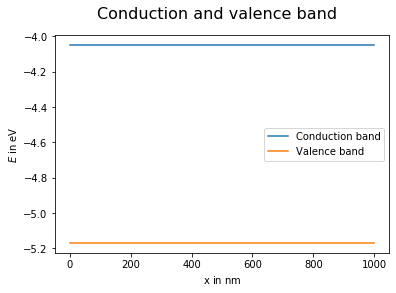

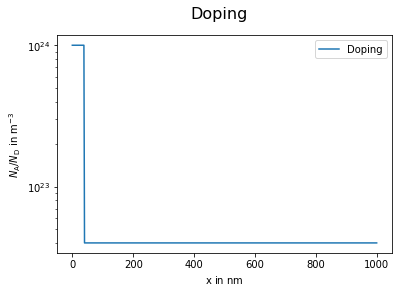

In [3]:
#
# Band diagram
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, -parameters.Chi, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, -parameters.Chi-parameters.Eg, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

#
# Doping level
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


## Solving without biasing
Now, let's apply a voltage of $0\,\mathrm{mV}$!.

In [4]:
solver.solve_from_doping()

solver.solve_no_bias()
bias_point = 0.0

solver.solve_bias(bias_point,0)

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


Norm of b:  0.07262608146001687
Norm of x: 4.4850105006988036e-13


True

## Plot the potential

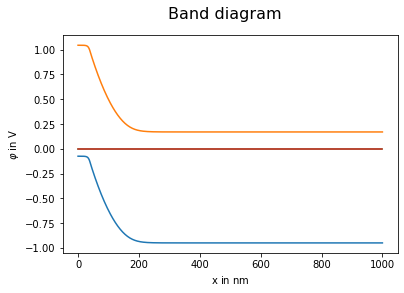

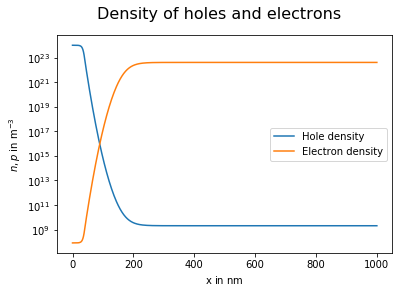

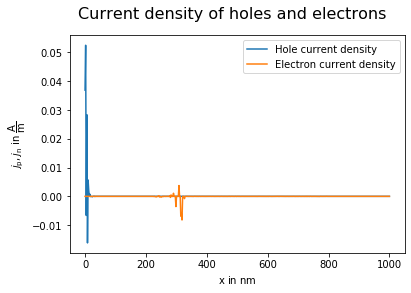

In [5]:
#
# Plot band diagram
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Band diagram", fontsize=16)

axis.plot(parameters.pos_x * 1E9, -parameters.u[0::3] - parameters.Chi -  parameters.Eg, label='Valence band')
axis.plot(parameters.pos_x * 1E9, -parameters.u[0::3] - parameters.Chi                 , label='Conduction band')
axis.plot(parameters.pos_x * 1E9, -parameters.u[1::3]                                  , label='Quasi-Fermi-level of holes')
axis.plot(parameters.pos_x * 1E9, -parameters.u[2::3]                                  , label='Quasi-Fermi-level of electrons')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

plt.show()

#
# Electron and hole density
#
calc_p_density()
calc_n_density()
p = calc_p_density()
n = calc_n_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n,p$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
plt.show()

## Simulation with illumination
Now we illuminate the solar cell and simulate the short circuit current density.<br>
We assume a powerdensity of $1\,\mathrm{\dfrac{kW}{m^3}}$,
an absorption coefficient for silicon of $\alpha_\mathrm{Si} = 2.0\cdot 10^{6}\,\mathrm{m^{-1}}$, and
a light efficiency of $\eta = 0.6$. <br>
For the simulation to converge, the illumination must be ramped up, this takes some time.<br>


In [6]:
# For the simulatoin the illumination starts
# 10nm after and stops 10nm before the contacts.
x1 = 10E-9
x2 = 990E-9


bias_point = 0.0

eta = 0.6

I0 = 1E3

alpha = 2E6

dI0 = alpha*I0*eta

steps = 23

for i in range(steps):

    print("Step:", i,
          "Generation rate at the surface",
          dI0/(2**steps) * 2**(i+1) /(parameters.q * Eg))

    parameters.generation = np.where((parameters.pos_x  > x1) & (parameters.pos_x < x2),
                                     dI0/(2**steps) * 2**(i+1) * np.exp(-parameters.pos_x*alpha) /(parameters.q * Eg),
                                     0)

    solver.solve_bias(-bias_point,0)
    
    j = np.mean(hole_current_density() + electron_current_density())
    
    print("\t Current density:", j)
    

Step: 0 Generation rate at the surface 1.596552985055106e+21
Norm of b:  0.09472884306237934
Norm of x: 6.602849205045295
Norm of b:  46.0843624917408
Norm of x: 0.49804881782512184
Norm of b:  16.954871686630494
Norm of x: 0.4868820825847066
Norm of b:  6.240113843979743
Norm of x: 0.475318531178908
Norm of b:  2.295720185603873
Norm of x: 0.46325581287337014
Norm of b:  0.8484050952135305
Norm of x: 0.4505663112714584
Norm of b:  0.3260583202007659
Norm of x: 0.4370453309297628
Norm of b:  0.1403612883365802
Norm of x: 0.42241963703188573
Norm of b:  0.11391484744690498
Norm of x: 0.40631733969043676
Norm of b:  0.13403709230768476
Norm of x: 0.38819648951850216
Norm of b:  0.11444306980826464
Norm of x: 0.367207283751316
Norm of b:  0.12064627237138187
Norm of x: 0.34193106314962035
Norm of b:  0.14681010214732892
Norm of x: 0.3099077519175108
Norm of b:  0.08038458307116109
Norm of x: 0.2669488680107674
Norm of b:  0.1218420644083302
Norm of x: 0.20709145209581714
Norm of b:  0.126

## Plot the parameters with illumination
* generation rate,
* hole and electron density, and
* hole and electron current density.

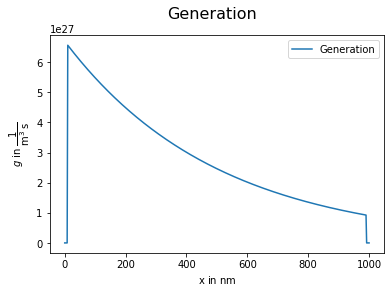

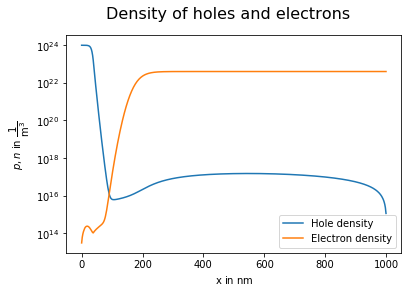

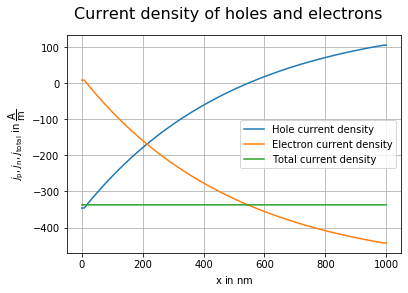

In [7]:
#
# Plot generation rate
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Generation", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.generation, label='Generation')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$g$ in $\mathrm{\dfrac{1}{m^3\, s}}$")

axis.legend()
plt.show()

#
# PLot hole and electron density
#
calc_p_density()
calc_n_density()

p = calc_p_density()
n = calc_n_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$p, n$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.legend()
plt.show()

#
# Plot hole and electron current density 
#
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
axis.grid()
plt.show()

## Voltage sweep
Now, the voltage is swept to get the characteristics of the solar cell for illumination

In [8]:
u_start = 0.0
u_stop  = 0.50
u_step  = 0.025

voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/u_step) + 2)
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

Norm of b:  0.12295955245957764
Norm of x: 4.860415303860071e-13
0.0 , -337.06953821430136
Norm of b:  85708876529.07965
Norm of x: 0.27277670372038026
Norm of b:  1080154.8038444838
Norm of x: 0.0036160477197812206
Norm of b:  3.747530119928939
Norm of x: 7.003575906944736e-05
Norm of b:  0.10032492785301708
Norm of x: 3.982053410923678e-08
0.023809523809523808 , -336.5004145956021
Norm of b:  85708992576.7314
Norm of x: 0.2717386068116757
Norm of b:  1055150.055422827
Norm of x: 0.0037234612904271866
Norm of b:  3.5649986312566786
Norm of x: 7.45100936049678e-05
Norm of b:  0.15534716490659442
Norm of x: 4.530199583485902e-08
0.047619047619047616 , -335.91983340042594
Norm of b:  85709107518.844
Norm of x: 0.2706939181692243
Norm of b:  1030387.2798031105
Norm of x: 0.0038398984772530665
Norm of b:  3.579837420032552
Norm of x: 7.95147777133642e-05
Norm of b:  0.10071168532451534
Norm of x: 5.184634140295768e-08
0.07142857142857142 , -335.3281353048194
Norm of b:  85709221363.60721
N

## Plot solar cell characteristics
* the current density and 
* the power density.

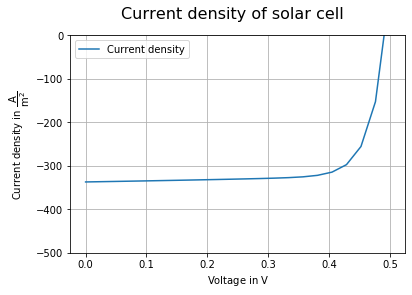

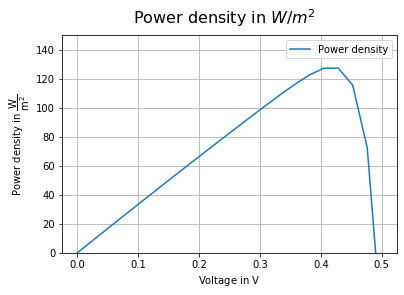

In [9]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of solar cell", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(-500,0)
plt.show()


# Power density
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Power density in $W/m^2$", fontsize=16)

axis.plot(voltage, -np.array(current_density)*np.array(voltage), label='Power density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Power density in $\mathrm{\dfrac{W}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(0,150)
plt.show()